# FIT5202 Assignment 2A : Building Models for Road Accident Prediction

## Table of Contents
*  
    * [Part 1 : Data Loading, Transformation and Exploration](#part-1)
    * [Part 2 : Feature extraction and ML training](#part-2)
    * [Part 3 : Hyperparameter Tuning and Model Optimisation](#part-3)  
Please add code/markdown cells as needed.

# Part 1: Data Loading, Transformation and Exploration <a class="anchor" name="part-1"></a>
## 1.1 Data Loading
In this section, I loaded the given datasets into PySpark DataFrames and use DataFrame functions to process the data. For plotting, various visualisation packages can be used, I ensure that I have included instructions to install the additional packages and that the installation will be successful in the provided Docker container.

### 1.1.1 Data Loading <a class="anchor" name="1.1"></a>
1.1.1 The code to create a SparkSession. For creating the SparkSession, I use a SparkConf object to configure the Spark app with a proper application name, to ensure the maximum partition size does not exceed 32MB, and to run locally with all CPU cores on my machine

In [1]:
from pyspark import SparkConf
from pyspark.sql import SparkSession
from pyspark import SparkContext

# Configure Spark to run locally.
master = "local[4]" 
app_name = "Assignment 2A : Building Models for Road Accident Prediction"

spark_conf = (
    SparkConf()
    .setMaster(master)
    .setAppName(app_name)
    .set("spark.sql.files.maxPartitionBytes", "32mb")
)

# Create SparkSession
spark = SparkSession.builder.config(conf=spark_conf).getOrCreate()

# Get sparkContext from active session
sc = spark.sparkContext
sc.setLogLevel('ERROR')

I used local[4] instead of local[*] because running all available cores caused memory pressure on my laptop.

1.1.2 Datasets schemas.

In [2]:
# Import library
from pyspark.sql.types import StructType, StructField, IntegerType, StringType, DoubleType, DateType

# Dataframes schema
accidents_schema = StructType([
    StructField("collision_index", StringType(), True),
    StructField("vehicle_reference", StringType(), True),
    StructField("casualty_reference", StringType(), True),
    StructField("casualty_class", StringType(), True),
    StructField("casualty_severity", StringType(), True),
    StructField("pedestrian_location", StringType(), True),
    StructField("pedestrian_movement", StringType(), True),
    StructField("car_passenger", StringType(), True),
    StructField("casualty_type", StringType(), True),
])

vehicles_schema = StructType([
    StructField("collision_index", StringType(), True),
    StructField("vehicle_reference", StringType(), True),
    StructField("vehicle_type", StringType(), True),
    StructField("vehicle_manoeuvre", StringType(), True),
    StructField("junction_location", StringType(), True),
    StructField("skidding_and_overturning", StringType(), True),
    StructField("hit_object_in_carriageway", StringType(), True),
    StructField("first_point_of_impact", StringType(), True),
    StructField("sex_of_driver", StringType(), True),
    StructField("age_of_driver", IntegerType(), True),
    StructField("engine_capacity_cc", IntegerType(), True),
    StructField("propulsion_code", StringType(), True),
    StructField("age_of_vehicle", IntegerType(), True),
])

collision_schema = StructType([
    StructField("collision_index", StringType(), True),
    StructField("longitude", DoubleType(), True),       
    StructField("latitude", DoubleType(), True),
    StructField("date", StringType(), True),
    StructField("time", StringType(), True),
    StructField("road_type", StringType(), True),
    StructField("speed_limit", StringType(), True),
    StructField("junction_detail", StringType(), True),
    StructField("junction_control", StringType(), True),
    StructField("pedestrian_crossing", StringType(), True),
    StructField("light_conditions", StringType(), True),
    StructField("weather_conditions", StringType(), True),
    StructField("road_surface_conditions", StringType(), True),
    StructField("carriageway_hazards", StringType(), True),
    StructField("urban_or_rural_area", StringType(), True),
    StructField("area", StringType(), True),
])

severity_schema = StructType([
    StructField("collision_index", StringType(), True),
    StructField("severity_rating", DoubleType(), True),
])

1.1.3 load the CSV files into separate data frames. 

In [3]:
# paths
path1 = 'A2/a2_accidents.csv'
path2 = 'A2/a2_vehicle.csv'
path3 = 'A2/a2_collision.csv'
path4 = 'A2/severity_rating.csv'

# Load accidents data
df_accidents = spark.read.csv(path1, header=True, schema=accidents_schema)

# Load vehicles data
df_vehicles = spark.read.csv(path2, header=True, schema=vehicles_schema)

# Load collision data
df_collision = spark.read.csv(path3, header=True, schema=collision_schema)

# Load severity data
df_severity = spark.read.csv(path4, header=True, schema=severity_schema)

print("Accidents DataFrame Schema:")
df_accidents.printSchema()

print("\nVehicles DataFrame Schema:")
df_vehicles.printSchema()

print("\nCollision DataFrame Schema:")
df_collision.printSchema()

print("\nSeverity DataFrame Schema:")
df_severity.printSchema()

df_accidents.show(5)
df_vehicles.show(5)
df_collision.show(5)
df_severity.show(5)

Accidents DataFrame Schema:
root
 |-- collision_index: string (nullable = true)
 |-- vehicle_reference: string (nullable = true)
 |-- casualty_reference: string (nullable = true)
 |-- casualty_class: string (nullable = true)
 |-- casualty_severity: string (nullable = true)
 |-- pedestrian_location: string (nullable = true)
 |-- pedestrian_movement: string (nullable = true)
 |-- car_passenger: string (nullable = true)
 |-- casualty_type: string (nullable = true)


Vehicles DataFrame Schema:
root
 |-- collision_index: string (nullable = true)
 |-- vehicle_reference: string (nullable = true)
 |-- vehicle_type: string (nullable = true)
 |-- vehicle_manoeuvre: string (nullable = true)
 |-- junction_location: string (nullable = true)
 |-- skidding_and_overturning: string (nullable = true)
 |-- hit_object_in_carriageway: string (nullable = true)
 |-- first_point_of_impact: string (nullable = true)
 |-- sex_of_driver: string (nullable = true)
 |-- age_of_driver: integer (nullable = true)
 |-- 

In [4]:
# Dateset partition check
dfs_partitions = [
    ("Collision", df_collision),
    ("Accident", df_accidents),
    ("Vehicle", df_vehicles),
    ("Severity", df_severity)
]

print(f"{'Table':<12} | {'Partitions':<10}")
print("-" * 25)

for name, df in dfs_partitions:
    num_part = df.rdd.getNumPartitions()
    print(f"{name:<12} | {num_part:<10}")

Table        | Partitions
-------------------------
Collision    | 23        
Accident     | 13        
Vehicle      | 23        
Severity     | 6         


The four datasets were loaded successfully using predefined schemas. The partition counts show that Spark has divided the CSV files into multiple partitions, allowing parallel processing. The collision and vehicle datasets have the largest number of partitions, while the severity dataset has fewer partitions because it contains fewer columns and is smaller. No repartitioning is applied at this stage because the current partitioning is sufficient for the initial transformation and exploration tasks.

### 1.2 Data Transformation to Create Features <a class="anchor" name="1.2"></a>
In this section, I primarily have three tasks:  
1.2.1 Data Aggregation: Join data frames to create a "flat" data frame for ML training

The collision dataset is used as the main collision-level dataset. The vehicle and accident datasets contain multiple records for the same collision, so they need to be aggregated by `collision_index` before joining. This avoids row duplication when creating the final machine learning dataframe. The severity rating dataset is joined as the label for model training.

In [5]:
from pyspark.sql import functions as F

summary_data = [
    (
        "Collision",
        df_collision.count(),
        df_collision.select(F.countDistinct("collision_index")).first()[0]
    ),
    (
        "Accident",
        df_accidents.count(),
        df_accidents.select(F.countDistinct("collision_index")).first()[0]
    ),
    (
        "Vehicle",
        df_vehicles.count(),
        df_vehicles.select(F.countDistinct("collision_index")).first()[0]
    ),
    (
        "Severity",
        df_severity.count(),
        df_severity.select(F.countDistinct("collision_index")).first()[0]
    )
]

summary_df = spark.createDataFrame(
    summary_data,
    ["table_name", "row_count", "distinct_collision_index"]
)

summary_df.show(truncate=False)

+----------+---------+------------------------+
|table_name|row_count|distinct_collision_index|
+----------+---------+------------------------+
|Collision |9015100  |9015100                 |
|Accident  |11974250 |9015100                 |
|Vehicle   |16099146 |9015100                 |
|Severity  |9015100  |9015100                 |
+----------+---------+------------------------+



In [6]:
# Aggregate accident data

from pyspark.sql import functions as F

df_accident_agg = df_accidents.groupBy("collision_index").agg(
    F.countDistinct(
        F.struct("vehicle_reference", "casualty_reference")
    ).alias("num_casualties"),

    F.max(
        F.when(F.col("casualty_class") == "3", 1).otherwise(0)
    ).alias("has_pedestrian_casualty")
)

df_accident_agg.show(5, truncate=False)

+---------------+--------------+-----------------------+
|collision_index|num_casualties|has_pedestrian_casualty|
+---------------+--------------+-----------------------+
|197901A5GJC57  |1             |0                      |
|197901A6XBE02  |1             |1                      |
|197901A9KAC50  |1             |1                      |
|197901A9NDX33  |1             |0                      |
|197901ACPCE38  |1             |1                      |
+---------------+--------------+-----------------------+
only showing top 5 rows


In [7]:
# Validate the result
print("Accident aggregated rows:", df_accident_agg.count())
print(
    "Distinct collision indexes:",
    df_accident_agg.select(F.countDistinct("collision_index")).first()[0]
)

Accident aggregated rows: 9015100
Distinct collision indexes: 9015100


In [8]:
# Aggregate Vehicle data
# Clean numerical vehicle columns before aggregation
df_vehicles_clean = df_vehicles \
    .withColumn(
        "age_of_driver_clean",
        F.when(
            F.col("age_of_driver").isNull() |
            (F.col("age_of_driver") == -1),
            F.lit(None).cast("double")
        ).otherwise(F.col("age_of_driver").cast("double"))
    ) \
    .withColumn(
        "engine_capacity_clean",
        F.when(
            F.col("engine_capacity_cc").isNull() |
            (F.col("engine_capacity_cc") == -1),
            F.lit(None).cast("double")
        ).otherwise(F.col("engine_capacity_cc").cast("double"))
    ) \
    .withColumn(
        "age_of_vehicle_clean",
        F.when(
            F.col("age_of_vehicle").isNull() |
            (F.col("age_of_vehicle") == -1),
            F.lit(None).cast("double")
        ).otherwise(F.col("age_of_vehicle").cast("double"))
    )

In [9]:
# Helper function
from pyspark.sql.window import Window
from pyspark.sql import functions as F

def get_mode_by_collision(df, column_name, output_name):
    mode_window = Window.partitionBy("collision_index").orderBy(F.desc("count"))

    return df \
        .filter(
            F.col(column_name).isNotNull() &
            (~F.col(column_name).isin("-1", "99"))
        ) \
        .groupBy("collision_index", column_name) \
        .count() \
        .withColumn("rank", F.row_number().over(mode_window)) \
        .filter(F.col("rank") == 1) \
        .select(
            "collision_index",
            F.col(column_name).alias(output_name)
        )

In [10]:
# Create mode-based vehicle features
df_main_vehicle_type = get_mode_by_collision(
    df_vehicles,
    "vehicle_type",
    "main_vehicle_type"
)

df_main_vehicle_manoeuvre = get_mode_by_collision(
    df_vehicles,
    "vehicle_manoeuvre",
    "main_vehicle_manoeuvre"
)

df_main_junction_location = get_mode_by_collision(
    df_vehicles,
    "junction_location",
    "main_junction_location"
)

df_main_sex_of_driver = get_mode_by_collision(
    df_vehicles,
    "sex_of_driver",
    "main_sex_of_driver"
)

df_main_propulsion_code = get_mode_by_collision(
    df_vehicles,
    "propulsion_code",
    "main_propulsion_code"
)

In [11]:
# Aggregate vehicle data by collision_index
motorcycle_codes = ["2", "3", "4", "5", "23", "97", "103", "104", "105", "106"]
large_vehicle_codes = ["10", "11", "19", "20", "21", "98", "110", "113"]

df_vehicle_agg = df_vehicles_clean.groupBy("collision_index").agg(
    F.countDistinct("vehicle_reference").alias("num_vehicles"),

    F.avg("age_of_driver_clean").alias("avg_age_of_driver"),
    F.avg("engine_capacity_clean").alias("avg_engine_capacity_cc"),
    F.avg("age_of_vehicle_clean").alias("avg_age_of_vehicle"),

    F.max(
        F.when(F.col("age_of_driver_clean") < 25, 1).otherwise(0)
    ).alias("has_young_driver"),

    F.max(
        F.when(F.col("age_of_driver_clean") >= 65, 1).otherwise(0)
    ).alias("has_old_driver"),

    F.max(
        F.when(F.col("vehicle_type").isin(motorcycle_codes), 1).otherwise(0)
    ).alias("has_motorcycle"),

    F.max(
        F.when(F.col("vehicle_type").isin(large_vehicle_codes), 1).otherwise(0)
    ).alias("has_large_vehicle"),

    F.max(
        F.when(
            F.col("skidding_and_overturning").isNotNull() &
            (~F.col("skidding_and_overturning").isin("0", "-1", "9")),
            1
        ).otherwise(0)
    ).alias("has_skidding_or_overturning"),

    F.max(
        F.when(
            F.col("hit_object_in_carriageway").isNotNull() &
            (~F.col("hit_object_in_carriageway").isin("0", "-1", "99")),
            1
        ).otherwise(0)
    ).alias("has_hit_object")
)

In [12]:
# Join mode-based features into vehicle aggregation

df_vehicle_agg = df_vehicle_agg \
    .join(df_main_vehicle_type, on="collision_index", how="left") \
    .join(df_main_vehicle_manoeuvre, on="collision_index", how="left") \
    .join(df_main_junction_location, on="collision_index", how="left") \
    .join(df_main_sex_of_driver, on="collision_index", how="left") \
    .join(df_main_propulsion_code, on="collision_index", how="left")

In [13]:
# Validate the result
print("Vehicle aggregated rows:", df_vehicle_agg.count())
print(
    "Distinct collision indexes:",
    df_vehicle_agg.select(F.countDistinct("collision_index")).first()[0]
)

Vehicle aggregated rows: 9015100
Distinct collision indexes: 9015100


The vehicle dataset contains multiple vehicle records for each collision. Therefore, it was aggregated by `collision_index` before joining with the collision and severity datasets. Numerical vehicle attributes were summarised using averages, while important vehicle conditions were converted into binary indicators. For categorical vehicle attributes, mode-based summaries were used instead of `first()` because one collision can involve multiple vehicles.

In [14]:
# Join the datasets
df_joined = df_collision \
    .join(df_accident_agg, on="collision_index", how="inner") \
    .join(df_vehicle_agg, on="collision_index", how="inner") \
    .join(df_severity, on="collision_index", how="inner")

In [15]:
# Check joined dataframe structure only
joined_cols = len(df_joined.columns)

print("Joined data columns:", joined_cols)
print("Expected joined rows: 9015100")
print("Expected distinct collision indexes: 9015100")

df_joined.printSchema()

df_joined.select(
    "collision_index",
    "date",
    "time",
    "road_type",
    "speed_limit",
    "weather_conditions",
    "road_surface_conditions",
    "num_casualties",
    "num_vehicles",
    "avg_age_of_driver",
    "severity_rating"
).show(5, truncate=False)

Joined data columns: 34
Expected joined rows: 9015100
Expected distinct collision indexes: 9015100
root
 |-- collision_index: string (nullable = true)
 |-- longitude: double (nullable = true)
 |-- latitude: double (nullable = true)
 |-- date: string (nullable = true)
 |-- time: string (nullable = true)
 |-- road_type: string (nullable = true)
 |-- speed_limit: string (nullable = true)
 |-- junction_detail: string (nullable = true)
 |-- junction_control: string (nullable = true)
 |-- pedestrian_crossing: string (nullable = true)
 |-- light_conditions: string (nullable = true)
 |-- weather_conditions: string (nullable = true)
 |-- road_surface_conditions: string (nullable = true)
 |-- carriageway_hazards: string (nullable = true)
 |-- urban_or_rural_area: string (nullable = true)
 |-- area: string (nullable = true)
 |-- num_casualties: long (nullable = false)
 |-- has_pedestrian_casualty: integer (nullable = true)
 |-- num_vehicles: long (nullable = false)
 |-- avg_age_of_driver: double 

After aggregating the accident and vehicle datasets, all four datasets are joined using `collision_index`. An inner join is used because the modelling dataset requires collision information, aggregated accident information, aggregated vehicle information, and the severity label. The row count and distinct collision index count are checked to confirm that the joined dataframe still contains one row per collision and that no duplicate collision records were created during the join. 

The joined dataframe contains 9,015,100 rows and 9,015,100 distinct collision indexes. This confirms that the aggregation and join process successfully produced one row per collision. The accident and vehicle datasets were first aggregated by `collision_index`, then joined with the collision and severity datasets. Therefore, the dataframe is now suitable for further data transformation, imputation, and feature creation.

#### 1.2.2 Perform imputation

In [16]:
# Check missing value for all columns
from pyspark.sql import functions as F

null_summary = df_joined.select([
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df_joined.columns
])

null_summary.show(truncate=False)

+---------------+---------+--------+----+----+---------+-----------+---------------+----------------+-------------------+----------------+------------------+-----------------------+-------------------+-------------------+----+--------------+-----------------------+------------+-----------------+----------------------+------------------+----------------+--------------+--------------+-----------------+---------------------------+--------------+-----------------+----------------------+----------------------+------------------+--------------------+---------------+
|collision_index|longitude|latitude|date|time|road_type|speed_limit|junction_detail|junction_control|pedestrian_crossing|light_conditions|weather_conditions|road_surface_conditions|carriageway_hazards|urban_or_rural_area|area|num_casualties|has_pedestrian_casualty|num_vehicles|avg_age_of_driver|avg_engine_capacity_cc|avg_age_of_vehicle|has_young_driver|has_old_driver|has_motorcycle|has_large_vehicle|has_skidding_or_overturning|ha

In [17]:
# Check unknown or missing codes based on metadata
# Only include columns that exist in df_joined

unknown_code_map = {
    # collision-level columns
    "road_type": ["-1", "9"],
    "speed_limit": ["-1", "99"],
    "junction_detail": ["-1", "99"],
    "junction_control": ["-1", "9"],
    "pedestrian_crossing": ["-1", "99"],
    "light_conditions": ["-1"],
    "weather_conditions": ["-1", "9"],
    "road_surface_conditions": ["-1", "9"],
    "carriageway_hazards": ["-1", "99"],
    "urban_or_rural_area": ["-1"],

    # aggregated vehicle summary columns
    "main_vehicle_type": ["-1", "99"],
    "main_vehicle_manoeuvre": ["-1", "99"],
    "main_junction_location": ["-1", "9"],
    "main_sex_of_driver": ["-1"],
    "main_propulsion_code": ["-1"]
}

# Safety check: keep only columns that actually exist in df_joined
unknown_code_map = {
    c: codes
    for c, codes in unknown_code_map.items()
    if c in df_joined.columns
}

unknown_summary = df_joined.select([
    F.sum(
        F.when(
            F.col(c).cast("string").isin(codes),
            1
        ).otherwise(0)
    ).alias(c)
    for c, codes in unknown_code_map.items()
])

unknown_summary.show(truncate=False)

+---------+-----------+---------------+----------------+-------------------+----------------+------------------+-----------------------+-------------------+-------------------+-----------------+----------------------+----------------------+------------------+--------------------+
|road_type|speed_limit|junction_detail|junction_control|pedestrian_crossing|light_conditions|weather_conditions|road_surface_conditions|carriageway_hazards|urban_or_rural_area|main_vehicle_type|main_vehicle_manoeuvre|main_junction_location|main_sex_of_driver|main_propulsion_code|
+---------+-----------+---------------+----------------+-------------------+----------------+------------------+-----------------------+-------------------+-------------------+-----------------+----------------------+----------------------+------------------+--------------------+
|149657   |96         |18627          |3552674         |179098             |1678            |121220            |23048                  |20504              |3

In [18]:
mode_column_summary = df_joined.select(
    F.sum(F.when(F.col("main_vehicle_type").isNull(), 1).otherwise(0))
        .alias("main_vehicle_type_null"),

    F.sum(F.when(F.col("main_vehicle_manoeuvre").isNull(), 1).otherwise(0))
        .alias("main_vehicle_manoeuvre_null"),

    F.sum(F.when(F.col("main_junction_location").isNull(), 1).otherwise(0))
        .alias("main_junction_location_null"),

    F.sum(F.when(F.col("main_sex_of_driver").isNull(), 1).otherwise(0))
        .alias("main_sex_of_driver_null"),

    F.sum(F.when(F.col("main_propulsion_code").isNull(), 1).otherwise(0))
        .alias("main_propulsion_code_null")
)

mode_column_summary.show(truncate=False)

+----------------------+---------------------------+---------------------------+-----------------------+-------------------------+
|main_vehicle_type_null|main_vehicle_manoeuvre_null|main_junction_location_null|main_sex_of_driver_null|main_propulsion_code_null|
+----------------------+---------------------------+---------------------------+-----------------------+-------------------------+
|3231                  |65900                      |6231780                    |4449                   |3445061                  |
+----------------------+---------------------------+---------------------------+-----------------------+-------------------------+



| Column                    | Missing or unknown count | Approx. issue          |
| ------------------------- | -----------------------: | ---------------------- |
| `longitude`, `latitude`   |                4,887,443 | Very high, around 54%  |
| `junction_control`        |        3,552,674 unknown | Very high, around 39%  |
| `urban_or_rural_area`     |        3,703,024 unknown | Very high, around 41%  |
| `avg_engine_capacity_cc`  |           3,517,655 null | Very high, around 39%  |
| `avg_age_of_vehicle`      |           3,513,392 null | Very high, around 39%  |
| `avg_age_of_driver`       |             285,819 null | Moderate, around 3.17% |
| `weather_conditions`      |          121,220 unknown | Low, around 1.34%      |
| `road_surface_conditions` |           23,048 unknown | Low, around 0.26%      |
| `speed_limit`             |         very small issue | Almost complete        |
| `main_vehicle_type`	    | 3,231 null               | Can be handled later as categorical unknown |
| `main_vehicle_manoeuvre`	| 65,900 null	           | Can be handled later as categorical unknown |
| `main_junction_location`	| 6,231,780 null	       | Too many missing values |
| `main_propulsion_code`	| 3,445,061 null	       | Too many missing values |


The missing value check shows that several columns contain either null values or metadata based unknown codes. Some columns, such as `main_junction_location`, `main_propulsion_code`, `longitude`, and `latitude`, have very high missingness, so they are not selected for imputation because simple replacement may introduce artificial patterns.

For imputation, I selected `avg_age_of_driver` and `road_surface_conditions`. The average driver age column is numerical and has a moderate number of missing values after aggregation, so median imputation is suitable. The road surface condition column has a small number of missing or unknown values and can be logically imputed using weather condition.

In [19]:
from pyspark.ml.feature import Imputer
from pyspark.sql import functions as F

df_final = df_joined

# Median imputation for avg_age_of_driver
age_imputer = Imputer(
    inputCols=["avg_age_of_driver"],
    outputCols=["avg_age_of_driver_imputed"]
).setStrategy("median")

age_imputer_model = age_imputer.fit(df_final)

df_age_imputed = age_imputer_model.transform(df_final)

In [20]:
# Find the most common valid road surface condition for imputation

road_surface_mode = df_age_imputed \
    .filter(
        F.col("road_surface_conditions").isNotNull() &
        (~F.col("road_surface_conditions").isin("-1", "9"))
    ) \
    .groupBy("road_surface_conditions") \
    .count() \
    .orderBy(F.desc("count")) \
    .first()[0]

print("Most common valid road surface condition:", road_surface_mode)

Most common valid road surface condition: 1


In [21]:
# Weather based road surface imputation

df_final_cleaned = df_age_imputed.withColumn(
    "road_surface_conditions_imputed",
    F.when(
        F.col("road_surface_conditions").isNull() |
        F.col("road_surface_conditions").isin("-1", "9"),
        F.when(F.col("weather_conditions").isin("2", "5"), "2")
         .when(F.col("weather_conditions").isin("3", "6"), "3")
         .otherwise(F.lit(road_surface_mode))
    ).otherwise(F.col("road_surface_conditions"))
)

In [22]:
# Verify the result
df_final_cleaned.select(
    F.count("*").alias("total_rows"),

    F.sum(
        F.when(F.col("avg_age_of_driver").isNull(), 1).otherwise(0)
    ).alias("avg_age_before_imputation_null"),

    F.sum(
        F.when(F.col("avg_age_of_driver_imputed").isNull(), 1).otherwise(0)
    ).alias("avg_age_after_imputation_null"),

    F.sum(
        F.when(
            F.col("road_surface_conditions").isNull() |
            F.col("road_surface_conditions").isin("-1", "9"),
            1
        ).otherwise(0)
    ).alias("road_surface_before_imputation_missing_unknown"),

    F.sum(
        F.when(
            F.col("road_surface_conditions_imputed").isNull() |
            F.col("road_surface_conditions_imputed").isin("-1", "9"),
            1
        ).otherwise(0)
    ).alias("road_surface_after_imputation_missing_unknown")
).show(truncate=False)

+----------+------------------------------+-----------------------------+----------------------------------------------+---------------------------------------------+
|total_rows|avg_age_before_imputation_null|avg_age_after_imputation_null|road_surface_before_imputation_missing_unknown|road_surface_after_imputation_missing_unknown|
+----------+------------------------------+-----------------------------+----------------------------------------------+---------------------------------------------+
|9015100   |285819                        |0                            |23048                                         |0                                            |
+----------+------------------------------+-----------------------------+----------------------------------------------+---------------------------------------------+



For road surface imputation, I used the relationship between weather and road surface condition. When the weather condition indicated rain, missing or unknown road surface values were imputed as wet or damp. When the weather condition indicated snow, they were imputed as snow. For other weather conditions, the most common valid road surface condition was used as a fallback. The mode was `1`, which represents dry road surface. This avoids assigning unsupported values, for example treating high wind as snow or ice.

1.2.3 Feature Engineering

In [23]:
from pyspark.sql import functions as F

# Extract hour from accident time
feature_df = df_final_cleaned.withColumn(
    "Hour", 
    F.hour(F.to_timestamp(F.col("time"), "HH:mm")))

# Create peak traffic feature
feature_df = feature_df.withColumn(
    "Peak_Traffic",
    F.when(F.col("Hour").isNull(), "Unknown")
     .when(
        ((F.col("hour") >= 7) & (F.col("hour") <= 9)) | 
        ((F.col("hour") >= 16) & (F.col("hour") <= 18)), 
        "Peak"
    ).otherwise("Off-peak")
)

# Create additional feature based on bad light and bad weather condition
bad_condition_filter = (
    F.col("light_conditions").isin("4", "5", "6", "7") &
    F.col("weather_conditions").isin("2", "3", "5", "6", "7", "8")
)

feature_df = feature_df.withColumn(
    "Bad_Condition_Risk",
    F.when(bad_condition_filter, 1).otherwise(0)
)


In [24]:
# Verify the result
feature_df.select(
    "time",
    "Hour",
    "Peak_Traffic",
    "light_conditions",
    "weather_conditions",
    "Bad_Condition_Risk",
    "severity_rating"
).show(10, truncate=False)

+-----+----+------------+----------------+------------------+------------------+---------------+
|time |Hour|Peak_Traffic|light_conditions|weather_conditions|Bad_Condition_Risk|severity_rating|
+-----+----+------------+----------------+------------------+------------------+---------------+
|08:00|8   |Peak        |1               |3                 |0                 |2.0            |
|18:40|18  |Peak        |4               |3                 |1                 |2.0            |
|09:05|9   |Peak        |1               |8                 |0                 |3.0            |
|10:20|10  |Off-peak    |1               |8                 |0                 |2.0            |
|14:35|14  |Off-peak    |1               |8                 |0                 |3.0            |
|15:00|15  |Off-peak    |1               |8                 |0                 |3.0            |
|15:10|15  |Off-peak    |1               |8                 |0                 |3.0            |
|06:45|6   |Off-peak    |4    

Because the feature is created at the hour level, the peak periods are represented as 07:00–09:59 and 16:00–18:59. This follows the assignment's example of using morning and afternoon peak traffic periods.

In [25]:
# Check counts
feature_df.groupBy("Peak_Traffic").count().show()

feature_df.groupBy("Bad_Condition_Risk").count().show()

+------------+-------+
|Peak_Traffic|  count|
+------------+-------+
|    Off-peak|5499513|
|        Peak|3515579|
|     Unknown|      8|
+------------+-------+

+------------------+-------+
|Bad_Condition_Risk|  count|
+------------------+-------+
|                 1| 700184|
|                 0|8314916|
+------------------+-------+



The feature engineering step created two new features. First, `Hour` was extracted from the accident time, and `Peak_Traffic` was created to separate collisions occurring during morning and afternoon peak periods from off-peak collisions. The output shows that 3,515,579 collisions occurred during peak periods and 5,499,521 occurred during off-peak periods. 

Second, `Bad_Condition_Risk` was created from the combination of poor light conditions and adverse weather conditions. It is coded as 1 when both conditions are present and 0 otherwise. The output shows that 700,184 collisions occurred under bad condition risk, while 8,314,916 did not.

In [26]:
feature_df.filter(F.col("Hour").isNull()) \
    .select("collision_index", "date", "time", "Hour", "Peak_Traffic") \
    .show(10, truncate=False)

+---------------+----+----+----+------------+
|collision_index|date|time|Hour|Peak_Traffic|
+---------------+----+----+----+------------+
|19915591E1004  |NULL|NULL|NULL|Unknown     |
|19925592C0236  |NULL|NULL|NULL|Unknown     |
|19905590E0704  |NULL|NULL|NULL|Unknown     |
|199016D040035  |NULL|NULL|NULL|Unknown     |
|19905590C1490  |NULL|NULL|NULL|Unknown     |
|19915591C1422  |NULL|NULL|NULL|Unknown     |
|19925592E0203  |NULL|NULL|NULL|Unknown     |
|1997610054197  |NULL|NULL|NULL|Unknown     |
+---------------+----+----+----+------------+



There are 8 null values in the `Hour` column because 8 records have missing accident time. Since `Hour` is extracted from the `time` column, Spark cannot calculate an hour value when time is missing. These records represent a very small proportion of the dataset, so they are assigned to an `Unknown` peak traffic category.

In [27]:
# Safe dataframe feature into parquet
feature_df.write.mode("overwrite").parquet("A2/feature_df_parquet")

### 1.3 Exploring the Data <a class="anchor" name="1.3"></a>

a) For each numeric column, show count, mean, stddev, min, max, 25 percentile, 50 percentile, 75 percentile;  
b) For each non-numeric column, display the top-5 values and the corresponding counts;  
c) Display the value and count.

In [28]:
# Define column groups
from pyspark.sql import functions as F
from pyspark.sql.types import NumericType, StringType

# Re-read the data from parquet
feature_df = spark.read.parquet("A2/feature_df_parquet")

# Define numeric columns for summary statistics
numeric_cols = [
    "longitude",
    "latitude",
    "num_casualties",
    "num_vehicles",
    "avg_age_of_driver_imputed",
    "avg_engine_capacity_cc",
    "avg_age_of_vehicle",
    "Hour",
    "severity_rating"
]

numeric_cols = [c for c in numeric_cols if c in feature_df.columns]

# Define categorical columns
categorical_cols = [
    "road_type",
    "speed_limit",
    "junction_detail",
    "junction_control",
    "pedestrian_crossing",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions_imputed",
    "carriageway_hazards",
    "urban_or_rural_area",
    "area",
    "main_vehicle_type",
    "main_vehicle_manoeuvre",
    "main_junction_location",
    "main_sex_of_driver",
    "main_propulsion_code",
    "Peak_Traffic"
]

categorical_cols = [c for c in categorical_cols if c in feature_df.columns]

# Define binary columns
binary_cols = [
    "has_pedestrian_casualty",
    "has_young_driver",
    "has_old_driver",
    "has_motorcycle",
    "has_large_vehicle",
    "has_skidding_or_overturning",
    "has_hit_object",
    "Bad_Condition_Risk"
]

binary_cols = [c for c in binary_cols if c in feature_df.columns]

In [29]:
# a) For each numeric column: count, mean, stddev, min, max, and percentiles
numeric_summary = feature_df.select(numeric_cols).summary(
    "count", "mean", "stddev", "min", "25%", "50%", "75%", "max"
)

# numeric_summary.show(truncate=False)
numeric_summary_pd = numeric_summary.toPandas()

numeric_summary_table = numeric_summary_pd.set_index("summary").T.reset_index()
numeric_summary_table = numeric_summary_table.rename(columns={"index": "column"})

display(numeric_summary_table)

summary,column,count,mean,stddev,min,25%,50%,75%,max
0,longitude,4127657,-1.3896176027169873,1.3948801931841308,-7.536169,-2.295085,-1.3423,-0.194689,1.76201
1,latitude,4127657,52.535685240601836,1.4223322465300767,49.91221,51.485123,52.198418,53.44417,60.801662
2,num_casualties,9015100,1.328243724417921,0.8164514475386955,1,1,1,1,93
3,num_vehicles,9015100,1.7857978280884295,0.7260429110213544,1,1,2,2,192
4,avg_age_of_driver_imputed,9015100,35.973164033178044,12.805558474339486,0.0,26.5,34.5,43.5,100.0
5,avg_engine_capacity_cc,5497445,1804.2048615611109,1455.7224406246164,1.0,1292.5,1593.0,1896.0,99999.0
6,avg_age_of_vehicle,5501708,6.90046194580447,4.19985710991951,0.0,4.0,6.5,9.5,123.0
7,Hour,9015092,13.842281698289934,5.257602208547227,0,10,15,18,23
8,severity_rating,9015100,3.011786558108063,1.0447217009174063,1.0,2.0,3.0,4.0,10.0


The numeric summary shows that the dataset is large and contains some skewed variables. Most collisions involve one casualty and one or two vehicles, but the maximum values for casualties and vehicles are much larger, indicating rare extreme cases. The severity rating has a median of 3 and a 75th percentile of 4, suggesting that lower severity ratings dominate the dataset. Some variables, such as longitude, latitude, engine capacity, and vehicle age, contain missing values or extreme values, so they need careful consideration before model training.

In [30]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# Select only categorical columns to reduce data scanned
categorical_selected_df = feature_df.select(categorical_cols)

# Convert wide categorical columns into long format
stack_expr = ", ".join([
    f"'{c}', COALESCE(CAST(`{c}` AS STRING), 'NULL')"
    for c in categorical_cols
])

categorical_long_df = categorical_selected_df.selectExpr(
    f"stack({len(categorical_cols)}, {stack_expr}) as (column_name, value)"
)

# Count each value within each categorical column
categorical_counts_df = categorical_long_df.groupBy(
    "column_name",
    "value"
).count()

# Rank values inside each column
window_spec = Window.partitionBy("column_name").orderBy(F.desc("count"))

top5_categorical_df = categorical_counts_df \
    .withColumn("rank", F.row_number().over(window_spec)) \
    .filter(F.col("rank") <= 5) \
    .orderBy("column_name", "rank")

top5_categorical_df.show(200, truncate=False)

+-------------------------------+-------------------+-------+----+
|column_name                    |value              |count  |rank|
+-------------------------------+-------------------+-------+----+
|Peak_Traffic                   |Off-peak           |5499513|1   |
|Peak_Traffic                   |Peak               |3515579|2   |
|Peak_Traffic                   |Unknown            |8      |3   |
|area                           |Metropolitan Police|1574269|1   |
|area                           |Greater Manchester |393987 |2   |
|area                           |West Midlands      |368155 |3   |
|area                           |West Yorkshire     |326797 |4   |
|area                           |Thames Valley      |309638 |5   |
|carriageway_hazards            |0                  |8569800|1   |
|carriageway_hazards            |13                 |115963 |2   |
|carriageway_hazards            |17                 |103939 |3   |
|carriageway_hazards            |20                 |77068  |4

The categorical summary shows that several road and environmental variables are strongly dominated by common conditions. Most collisions occurred on road type 6, at a 30 mph speed limit, under fine weather, and on dry road surfaces. The `Peak_Traffic` feature shows that off-peak collisions are more common than peak-time collisions.

Some categorical columns contain many missing or unknown values. For example, `junction_control` and `urban_or_rural_area` contain many `-1` values, while `main_junction_location` and `main_propulsion_code` contain many null values. These columns may be less reliable for model training and need careful consideration during feature selection.

In [31]:
# c) For each "boolean-like" column: value and count

from pyspark.sql import functions as F
from pyspark.sql.window import Window

# Select only binary columns
binary_selected_df = feature_df.select(binary_cols)

# Convert wide binary columns into long format
stack_expr = ", ".join([
    f"'{c}', CAST(`{c}` AS STRING)"
    for c in binary_cols
])

binary_long_df = binary_selected_df.selectExpr(
    f"stack({len(binary_cols)}, {stack_expr}) as (column_name, value)"
)

# Count each value within each binary column
binary_counts_df = binary_long_df.groupBy(
    "column_name",
    "value"
).count()

# Order the result
binary_counts_df = binary_counts_df.orderBy(
    "column_name",
    "value"
)

binary_counts_df.show(100, truncate=False)

+---------------------------+-----+-------+
|column_name                |value|count  |
+---------------------------+-----+-------+
|Bad_Condition_Risk         |0    |8314916|
|Bad_Condition_Risk         |1    |700184 |
|has_hit_object             |0    |8258241|
|has_hit_object             |1    |756859 |
|has_large_vehicle          |0    |7371403|
|has_large_vehicle          |1    |1643697|
|has_motorcycle             |0    |7563354|
|has_motorcycle             |1    |1451746|
|has_old_driver             |0    |8214396|
|has_old_driver             |1    |800704 |
|has_pedestrian_casualty    |0    |7241559|
|has_pedestrian_casualty    |1    |1773541|
|has_skidding_or_overturning|0    |6884289|
|has_skidding_or_overturning|1    |2130811|
|has_young_driver           |0    |5533202|
|has_young_driver           |1    |3481898|
+---------------------------+-----+-------+



The binary feature summary shows that most collisions do not involve pedestrian casualties, motorcycles, large vehicles, object impacts, or bad condition risk. However, some indicators still appear in a substantial number of records. For example, 3,481,898 collisions involve at least one young driver, 2,130,811 involve skidding or overturning, and 1,773,541 involve pedestrian casualties. These binary summaries help identify potentially important risk factors for later modelling.

2.	Explore the dataframe and present two plots of multivariate analysis.

Plot 1: Average severity by Peak_Traffic and Bad_Condition_Risk

In [32]:
plot1_df = feature_df.groupBy(
    "Peak_Traffic",
    "Bad_Condition_Risk"
).agg(
    F.count("*").alias("collision_count"),
    F.avg("severity_rating").alias("avg_severity")
).orderBy(
    "Peak_Traffic",
    "Bad_Condition_Risk"
)

plot1_df.show(truncate=False)

+------------+------------------+---------------+-----------------+
|Peak_Traffic|Bad_Condition_Risk|collision_count|avg_severity     |
+------------+------------------+---------------+-----------------+
|Off-peak    |0                 |5020637        |2.929283475383701|
|Off-peak    |1                 |478876         |2.797482020397765|
|Peak        |0                 |3294272        |3.16574709070775 |
|Peak        |1                 |221307         |3.055420750360359|
|Unknown     |0                 |7              |2.857142857142857|
|Unknown     |1                 |1              |3.0              |
+------------+------------------+---------------+-----------------+



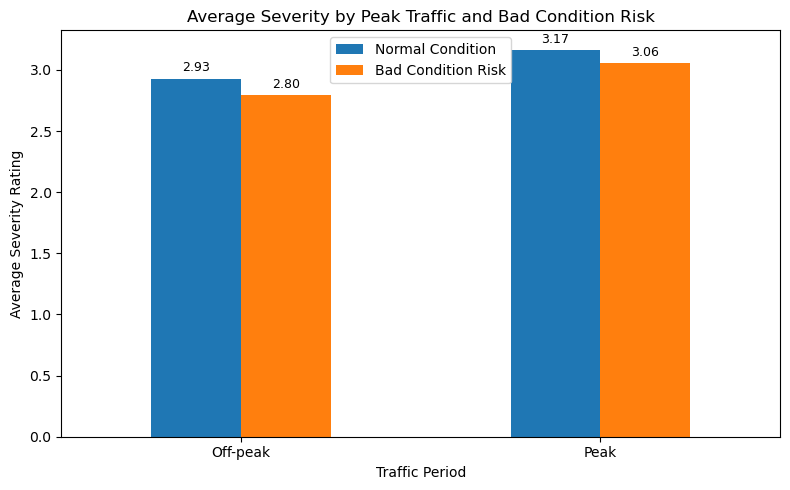

In [33]:
import matplotlib.pyplot as plt

plot1_pd = plot1_df.filter(F.col("Peak_Traffic") != "Unknown").toPandas()

plot1_pivot = plot1_pd.pivot(
    index="Peak_Traffic",
    columns="Bad_Condition_Risk",
    values="avg_severity"
)

ax = plot1_pivot.plot(kind="bar", figsize=(8, 5))

plt.title("Average Severity by Peak Traffic and Bad Condition Risk")
plt.xlabel("Traffic Period")
plt.ylabel("Average Severity Rating")
plt.xticks(rotation=0)
plt.legend(["Normal Condition", "Bad Condition Risk"])
plt.tight_layout()

# Add value labels on bars
for container in ax.containers:
    labels = [f"{bar.get_height():.2f}" for bar in container]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.show()

The first plot compares average severity rating by traffic period and bad condition risk. Peak traffic periods show higher average severity than off-peak periods in both normal and bad condition groups. This suggests that time of day may be related to accident severity, possibly because peak periods involve higher traffic density and more interaction between vehicles and pedestrians. Interestingly, bad condition risk has slightly lower average severity than normal conditions. This does not mean that bad conditions are safer. A possible explanation is that drivers may reduce speed during poor light and adverse weather, while normal conditions may allow faster driving. Therefore, `Peak_Traffic` appears useful for modelling, while `Bad_Condition_Risk` should be interpreted together with other road and traffic variables.

Plot 2: Average severity by speed_limit and road_surface_conditions_imputed

In [34]:
plot2_df = feature_df.filter(
    F.col("speed_limit").isin("20", "30", "40", "50", "60", "70")
).groupBy(
    "speed_limit",
    "road_surface_conditions_imputed"
).agg(
    F.count("*").alias("collision_count"),
    F.avg("severity_rating").alias("avg_severity")
).filter(
    F.col("collision_count") >= 1000
).orderBy(
    "speed_limit",
    "road_surface_conditions_imputed"
)

plot2_df.show(50, truncate=False)

+-----------+-------------------------------+---------------+------------------+
|speed_limit|road_surface_conditions_imputed|collision_count|avg_severity      |
+-----------+-------------------------------+---------------+------------------+
|20         |1                              |114300         |3.3758880139982503|
|20         |2                              |29755          |3.37203831288859  |
|30         |1                              |4080764        |2.967566122422174 |
|30         |2                              |1689196        |2.9278757468049887|
|30         |3                              |29440          |2.76796875        |
|30         |4                              |76508          |2.882535159721859 |
|30         |5                              |2657           |2.98118178396688  |
|30         |6                              |1386           |3.113997113997114 |
|40         |1                              |449973         |3.1145779857902585|
|40         |2              

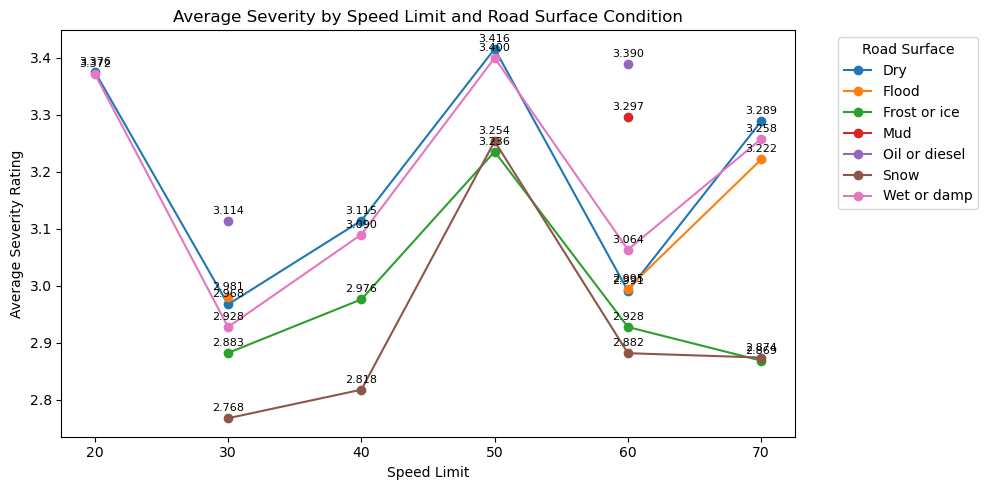

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

plot2_pd = plot2_df.toPandas()

surface_labels = {
    "1": "Dry",
    "2": "Wet or damp",
    "3": "Snow",
    "4": "Frost or ice",
    "5": "Flood",
    "6": "Oil or diesel",
    "7": "Mud"
}

plot2_pd["road_surface_label"] = plot2_pd["road_surface_conditions_imputed"].map(surface_labels)
plot2_pd["speed_limit"] = plot2_pd["speed_limit"].astype(int)

plot2_pivot = plot2_pd.pivot(
    index="speed_limit",
    columns="road_surface_label",
    values="avg_severity"
)

plot2_pivot = plot2_pivot.sort_index()

ax = plot2_pivot.plot(kind="line", marker="o", figsize=(10, 5))

plt.title("Average Severity by Speed Limit and Road Surface Condition")
plt.xlabel("Speed Limit")
plt.ylabel("Average Severity Rating")
plt.xticks(plot2_pivot.index)
plt.legend(title="Road Surface", bbox_to_anchor=(1.05, 1), loc="upper left")

# Add value labels to each visible point
for col in plot2_pivot.columns:
    for x, y in zip(plot2_pivot.index, plot2_pivot[col]):
        if pd.notna(y):
            ax.annotate(
                f"{y:.3f}",
                (x, y),
                textcoords="offset points",
                xytext=(0, 5),
                ha="center",
                fontsize=8
            )

plt.tight_layout()
plt.show()

The second plot compares average severity rating across speed limits and road surface conditions. The pattern is not perfectly linear, but speed limit appears to affect severity. Collisions at 50 mph and 70 mph generally show higher average severity than collisions at 30 mph, even though 30 mph is the most common speed limit in the dataset. Road surface condition also changes the pattern. Dry and wet surfaces have similar severity in many speed groups, while snow and frost or ice tend to show lower average severity in several groups. This may be because drivers reduce speed under visibly hazardous surface conditions. Overall, the plot suggests that speed limit and road surface condition are useful pre-crash variables for severity prediction.

## Part 2. Feature extraction and ML training <a class="anchor" name="part-2"></a>

#### 2.1.1 Discussion: Feature Selection and Transformation Strategy

Based on the objective of assisting emergency dispatchers, I selected features that are likely to be available before or during the early accident reporting stage. The selected features represent road, environmental, time, driver, and vehicle conditions. Road and environmental features include `road_type`, `speed_limit`, `light_conditions`, `weather_conditions`, and `road_surface_conditions_imputed`. These variables describe the physical condition of the accident location. The engineered features `Hour`, `Peak_Traffic`, and `Bad_Condition_Risk` are also included because the exploration showed that average severity differs across traffic periods and environmental risk groups.

Vehicle and driver summary features are included using collision-level aggregation. These include `num_vehicles`, `avg_age_of_driver_imputed`, `has_young_driver`, `has_old_driver`, `has_motorcycle`, `has_large_vehicle`, `main_vehicle_type`, and `main_vehicle_manoeuvre`. These features summarise human and vehicle factors without keeping multiple vehicle rows per collision.

Several columns are removed. `collision_index`, `date`, and `time` are excluded because they are identifiers or raw time fields that have already been transformed. `longitude`, `latitude`, `avg_engine_capacity_cc`, `avg_age_of_vehicle`, `main_junction_location`, and `main_propulsion_code` are excluded because they contain high missingness or extreme values. Casualty-related variables such as `num_casualties` and `has_pedestrian_casualty` are also excluded because they may only be known after the crash and could introduce data leakage.

Categorical variables will be transformed using `StringIndexer` and `OneHotEncoder`, while numerical and binary variables will be assembled using `VectorAssembler`. Since `severity_rating` is a numerical scale from 1 to 10, this task is treated as a regression problem. Random Forest and Gradient-boosted Tree regression models will be compared.

2.1.2 Create/transform the columns based on my thoughts above.

In [36]:
from pyspark.sql import functions as F

# Continuous / count features
numeric_features = [
    "speed_limit_num",
    "num_vehicles",
    "avg_age_of_driver_imputed",
    "Hour_clean"
]

# Binary indicator features
binary_features = [
    "Bad_Condition_Risk",
    "has_young_driver",
    "has_old_driver",
    "has_motorcycle",
    "has_large_vehicle"
]

# Categorical features to be indexed/encoded later
categorical_features = [
    "road_type_clean",
    "light_conditions_clean",
    "weather_conditions_clean",
    "road_surface_conditions_clean",
    "main_vehicle_type_clean",
    "main_vehicle_manoeuvre_clean",
    "Peak_Traffic_clean"
]

In [37]:
# Create clean modelling columns
model_df = feature_df \
    .withColumn(
        "label",
        F.col("severity_rating").cast("double")
    ) \
    .withColumn(
        "Hour_clean",
        F.when(F.col("Hour").isNull(), F.lit(-1.0))
         .otherwise(F.col("Hour").cast("double"))
    ) \
    .withColumn(
        "speed_limit_num",
        F.when(
            F.col("speed_limit").isNull() |
            F.col("speed_limit").isin("-1", "99"),
            F.lit(30.0)       # 30 mph is the most common speed limit in exploration
        ).otherwise(F.col("speed_limit").cast("double"))
    ) \
    .withColumn(
        "road_type_clean",
        F.when(
            F.col("road_type").isNull() |
            F.col("road_type").isin("-1", "9"),
            "Unknown"
        ).otherwise(F.col("road_type"))
    ) \
    .withColumn(
        "light_conditions_clean",
        F.when(
            F.col("light_conditions").isNull() |
            F.col("light_conditions").isin("-1"),
            "Unknown"
        ).otherwise(F.col("light_conditions"))
    ) \
    .withColumn(
        "weather_conditions_clean",
        F.when(
            F.col("weather_conditions").isNull() |
            F.col("weather_conditions").isin("-1", "9"),
            "Unknown"
        ).otherwise(F.col("weather_conditions"))
    ) \
    .withColumn(
        "road_surface_conditions_clean",
        F.when(
            F.col("road_surface_conditions_imputed").isNull() |
            F.col("road_surface_conditions_imputed").isin("-1", "9"),
            "Unknown"
        ).otherwise(F.col("road_surface_conditions_imputed"))
    ) \
    .withColumn(
        "main_vehicle_type_clean",
        F.when(
            F.col("main_vehicle_type").isNull() |
            F.col("main_vehicle_type").isin("-1", "99"),
            "Unknown"
        ).otherwise(F.col("main_vehicle_type"))
    ) \
    .withColumn(
        "main_vehicle_manoeuvre_clean",
        F.when(
            F.col("main_vehicle_manoeuvre").isNull() |
            F.col("main_vehicle_manoeuvre").isin("-1", "99"),
            "Unknown"
        ).otherwise(F.col("main_vehicle_manoeuvre"))
    ) \
    .withColumn(
        "Peak_Traffic_clean",
        F.when(F.col("Peak_Traffic").isNull(), "Unknown")
         .otherwise(F.col("Peak_Traffic"))
    )

In [38]:
# Cast binary features to double for VectorAssembler
for col_name in binary_features:
    model_df = model_df.withColumn(
        col_name,
        F.col(col_name).cast("double")
    )

# Keep only selected modelling columns
selected_model_cols = numeric_features + binary_features + categorical_features + ["label"]

model_df = model_df.select(selected_model_cols)

In [39]:
# Validate the modelling dataframe
model_df_rows = model_df.count() 
model_df_cols = len(model_df.columns)
print(f"model_df shape: , ({model_df_rows},{model_df_cols})" )

model_df.printSchema()

model_df.show(5, truncate=False)

model_df shape: , (9015100,17)
root
 |-- speed_limit_num: double (nullable = true)
 |-- num_vehicles: long (nullable = true)
 |-- avg_age_of_driver_imputed: double (nullable = true)
 |-- Hour_clean: double (nullable = true)
 |-- Bad_Condition_Risk: double (nullable = true)
 |-- has_young_driver: double (nullable = true)
 |-- has_old_driver: double (nullable = true)
 |-- has_motorcycle: double (nullable = true)
 |-- has_large_vehicle: double (nullable = true)
 |-- road_type_clean: string (nullable = true)
 |-- light_conditions_clean: string (nullable = true)
 |-- weather_conditions_clean: string (nullable = true)
 |-- road_surface_conditions_clean: string (nullable = true)
 |-- main_vehicle_type_clean: string (nullable = true)
 |-- main_vehicle_manoeuvre_clean: string (nullable = true)
 |-- Peak_Traffic_clean: string (nullable = true)
 |-- label: double (nullable = true)

+---------------+------------+-------------------------+----------+------------------+----------------+-------------

In [40]:
# Check null values
model_df.select([
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in model_df.columns
]).show(truncate=False)

+---------------+------------+-------------------------+----------+------------------+----------------+--------------+--------------+-----------------+---------------+----------------------+------------------------+-----------------------------+-----------------------+----------------------------+------------------+-----+
|speed_limit_num|num_vehicles|avg_age_of_driver_imputed|Hour_clean|Bad_Condition_Risk|has_young_driver|has_old_driver|has_motorcycle|has_large_vehicle|road_type_clean|light_conditions_clean|weather_conditions_clean|road_surface_conditions_clean|main_vehicle_type_clean|main_vehicle_manoeuvre_clean|Peak_Traffic_clean|label|
+---------------+------------+-------------------------+----------+------------------+----------------+--------------+--------------+-----------------+---------------+----------------------+------------------------+-----------------------------+-----------------------+----------------------------+------------------+-----+
|0              |0          

The final modelling dataframe contains 16 selected feature columns and one label column. These features include 4 numeric features, 5 binary indicator features, and 7 categorical features. The label column is `label`, derived from `severity_rating`.

### 2.2 Preparing Spark ML Transformers/Estimators for features, labels, and models  <a class="anchor" name="2.2"></a>

In [41]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import RandomForestRegressor, GBTRegressor

In [42]:
# Categorical features selected in Part 2.1
categorical_features = [
    "road_type_clean",
    "light_conditions_clean",
    "weather_conditions_clean",
    "road_surface_conditions_clean",
    "main_vehicle_type_clean",
    "main_vehicle_manoeuvre_clean",
    "Peak_Traffic_clean"
]

# Numerical and binary features selected in Part 2.1
numeric_features = [
    "speed_limit_num",
    "num_vehicles",
    "avg_age_of_driver_imputed",
    "Hour_clean"
]

binary_features = [
    "Bad_Condition_Risk",
    "has_young_driver",
    "has_old_driver",
    "has_motorcycle",
    "has_large_vehicle"
]

# Output columns for StringIndexer and OneHotEncoder
indexed_cols = [col_name + "_index" for col_name in categorical_features]
encoded_cols = [col_name + "_encoded" for col_name in categorical_features]

In [43]:
# Create StringIndexer and OneHotEncoder
indexer = StringIndexer(
    inputCols=categorical_features,
    outputCols=indexed_cols,
    handleInvalid="keep"
)

encoder = OneHotEncoder(
    inputCols=indexed_cols,
    outputCols=encoded_cols
)

In [44]:
# Create VectorAssembler
assembler_inputs = numeric_features + binary_features + encoded_cols

assembler = VectorAssembler(
    inputCols=assembler_inputs,
    outputCol="features",
    handleInvalid="keep"
)

In [45]:
# Create RF and GBT regression estimators
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="label",
    predictionCol="prediction",
    seed=2026
)

gbt = GBTRegressor(
    featuresCol="features",
    labelCol="label",
    predictionCol="prediction",
    seed=2026
)

I treat the task as a regression problem because severity_rating is a numerical score from 1 to 10. Regression is more suitable than multiclass classification because the severity scale has an ordered meaning. For example, predicting 4 instead of 5 is a smaller error than predicting 1 instead of 10. Therefore, I create Random Forest Regressor and Gradient-boosted Tree Regressor estimators.
Following the Spark ML pipeline structure from the applied class, categorical columns are first converted into numerical indices using StringIndexer, then encoded using OneHotEncoder. The encoded categorical vectors, numerical features, and binary features are combined into a single features vector using VectorAssembler. Two pipelines are created, one for Random Forest regression and one for GBT regression.

In [46]:
# Part 2.2: Create two Spark ML pipelines
# No fitting or transformation is performed in this section.

rf_pipeline = Pipeline(
    stages=[
        indexer,
        encoder,
        assembler,
        rf
    ]
)

gbt_pipeline = Pipeline(
    stages=[
        indexer,
        encoder,
        assembler,
        gbt
    ]
)

print("RF pipeline stages:")
for stage in rf_pipeline.getStages():
    print(stage.__class__.__name__)

print("\nGBT pipeline stages:")
for stage in gbt_pipeline.getStages():
    print(stage.__class__.__name__)

RF pipeline stages:
StringIndexer
OneHotEncoder
VectorAssembler
RandomForestRegressor

GBT pipeline stages:
StringIndexer
OneHotEncoder
VectorAssembler
GBTRegressor


In [47]:
# Save modelling dataframe to avoid recreating it during model training
model_df.write.mode("overwrite").parquet("A2/model_df_parquet")

### 2.3 Training and evaluating models  
2.3.1 Split the data for training and testing, using 2026 as the random seed.

In [48]:
from pyspark.sql import functions as F

# Re-read modelling dataframe from parquet
model_df = spark.read.parquet("A2/model_df_parquet")

# Split data into training and testing sets using seed 2026
train_df, test_df = model_df.randomSplit([0.7, 0.3], seed=2026)

# Save the split datasets to avoid repeating the random split later
train_df.write.mode("overwrite").parquet("A2/train_df_parquet")
test_df.write.mode("overwrite").parquet("A2/test_df_parquet")

# Re-read the saved split datasets
train_df = spark.read.parquet("A2/train_df_parquet")
test_df = spark.read.parquet("A2/test_df_parquet")

# Check split size
train_count = train_df.count()
test_count = test_df.count()
total_count = train_count + test_count

print("Training rows:", train_count)
print("Testing rows:", test_count)
print("Total rows:", total_count)
print("Training percentage:", round(train_count / total_count * 100, 2))
print("Testing percentage:", round(test_count / total_count * 100, 2))

Training rows: 6310526
Testing rows: 2704574
Total rows: 9015100
Training percentage: 70.0
Testing percentage: 30.0


2.3.2 Decide which metric is the best and implement the evaluation process.

Because this task is treated as a regression problem, I use RMSE, MAE, and R2 to evaluate model performance. RMSE penalises large prediction errors more strongly, which is useful because large mistakes in severity prediction can affect emergency response decisions. MAE is also useful because it is easier to interpret as the average prediction error in severity-rating points. R2 shows how much variation in severity is explained by the model. I use RMSE as the main comparison metric, while MAE and R2 are reported as supporting metrics.

In [49]:
from pyspark.ml.evaluation import RegressionEvaluator

# Main evaluator: lower RMSE is better
rmse_evaluator = RegressionEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="rmse"
)

# Additional evaluators for interpretation
mae_evaluator = RegressionEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="mae"
)

r2_evaluator = RegressionEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="r2"
)

def evaluate_regression_model(predictions, model_name):
    rmse = rmse_evaluator.evaluate(predictions)
    mae = mae_evaluator.evaluate(predictions)
    r2 = r2_evaluator.evaluate(predictions)

    print(model_name)
    print("RMSE:", round(rmse, 4))
    print("MAE:", round(mae, 4))
    print("R2:", round(r2, 4))

    return {
        "model": model_name,
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    }

2.3.3 Train, evaluate and Save the better model.

In [50]:
# Create smaller training/testing samples for first loop
# Re-read saved train and test data
train_df = spark.read.parquet("A2/train_df_parquet")
test_df = spark.read.parquet("A2/test_df_parquet")

# Use samples for early training loops to reduce runtime
train_sample_df = train_df.sample(withReplacement=False, fraction=0.2, seed=2026)
test_sample_df = test_df.sample(withReplacement=False, fraction=0.2, seed=2026)

print("Training sample rows:", train_sample_df.count())
print("Testing sample rows:", test_sample_df.count())

Training sample rows: 1263367
Testing sample rows: 541076


#### Iteration 1, baseline RF and GBT

In [51]:
# Iteration 1: baseline RF and GBT models on sampled data

# Random Forest (RF)
rf_model_1 = rf_pipeline.fit(train_sample_df)
rf_predictions_1 = rf_model_1.transform(test_sample_df)

rf_result_1 = evaluate_regression_model(
    rf_predictions_1,
    "Iteration 1 - Random Forest Baseline"
)

# Gradient boost Tree (GBT)
gbt_model_1 = gbt_pipeline.fit(train_sample_df)
gbt_predictions_1 = gbt_model_1.transform(test_sample_df)

gbt_result_1 = evaluate_regression_model(
    gbt_predictions_1,
    "Iteration 1 - GBT Baseline"
)

iteration_results = [rf_result_1, gbt_result_1]

Iteration 1 - Random Forest Baseline
RMSE: 0.8634
MAE: 0.705
R2: 0.3167
Iteration 1 - GBT Baseline
RMSE: 0.8339
MAE: 0.6573
R2: 0.3627


In Iteration 1, the GBT baseline model performed better than the Random Forest baseline model. GBT achieved lower RMSE and MAE, and a higher R2 score. This means the GBT model made smaller prediction errors and explained more variation in severity rating. Therefore, the next iteration focuses on improving the GBT model using a slightly larger number of boosting iterations.

#### Iteration 2, improve GBT only

In [52]:
from pyspark.ml.regression import GBTRegressor
from pyspark.ml import Pipeline

# Iteration 2: improved GBT model
gbt_iter2 = GBTRegressor(
    featuresCol="features",
    labelCol="label",
    predictionCol="prediction",
    maxIter=30,
    maxDepth=5,
    stepSize=0.1,
    seed=2026
)

gbt_iter2_pipeline = Pipeline(
    stages=[
        indexer,
        encoder,
        assembler,
        gbt_iter2
    ]
)

gbt_model_2 = gbt_iter2_pipeline.fit(train_sample_df)

gbt_predictions_2 = gbt_model_2.transform(test_sample_df)

gbt_result_2 = evaluate_regression_model(
    gbt_predictions_2,
    "Iteration 2 - GBT maxIter=30 maxDepth=5"
)

Iteration 2 - GBT maxIter=30 maxDepth=5
RMSE: 0.8283
MAE: 0.6517
R2: 0.3711


The sample-based iteration showed that GBT improved when maxIter was increased to 30 and maxDepth was set to 5.

The first two iterations were run on sampled training and testing data to reduce experimentation time. This helped identify that the GBT model with `maxIter=30` and `maxDepth=5` improved over the baseline GBT. For the next iteration, the selected GBT setting is trained on the full training dataset and evaluated on the full testing dataset. Also I will try to apply random forest model with the full datasets.

#### Iteration 3: train Random Forest and selected GBT on full data

In [53]:
# Iteration 3: train Random Forest on full training data

# Re-read full train and test data
# Random Forest
train_df = spark.read.parquet("A2/train_df_parquet")
test_df = spark.read.parquet("A2/test_df_parquet")

rf_final = RandomForestRegressor(
    featuresCol="features",
    labelCol="label",
    predictionCol="prediction",
    numTrees=20,
    maxDepth=5,
    seed=2026
)

rf_final_pipeline = Pipeline(
    stages=[
        indexer,
        encoder,
        assembler,
        rf_final
    ]
)

rf_final_model = rf_final_pipeline.fit(train_df)

In [54]:
# Random Forest evaluation
rf_final_predictions = rf_final_model.transform(test_df)

rf_final_result = evaluate_regression_model(
    rf_final_predictions,
    "Random Forest on Full Training Data"
)

Random Forest on Full Training Data
RMSE: 0.863
MAE: 0.705
R2: 0.3174


In [55]:
# Iteration 3: train improved GBT on full training data
# GBT
gbt_final = GBTRegressor(
    featuresCol="features",
    labelCol="label",
    predictionCol="prediction",
    maxIter=30,
    maxDepth=5,
    stepSize=0.1,
    seed=2026
)

gbt_final_pipeline = Pipeline(
    stages=[
        indexer,
        encoder,
        assembler,
        gbt_final
    ]
)

gbt_final_model = gbt_final_pipeline.fit(train_df)

In [56]:
# GBT Evaluation
gbt_final_predictions = gbt_final_model.transform(test_df)

gbt_final_result = evaluate_regression_model(
    gbt_final_predictions,
    "Iteration 3 - Final GBT on Full Training Data"
)

Iteration 3 - Final GBT on Full Training Data
RMSE: 0.8268
MAE: 0.6511
R2: 0.3734


The full-data evaluation shows that the Gradient-boosted Tree model outperformed the Random Forest model. GBT achieved lower RMSE and MAE and a higher R2 score, meaning it made smaller prediction errors and explained more variation in severity rating. The improvement from the sampled iteration to the full-data iteration was small, but the result is consistent. This suggests that the selected features capture some useful severity patterns, although the prediction task remains difficult because the dataset is skewed toward lower severity ratings and post-crash casualty features were excluded to avoid data leakage.

#### Iteration 4: Feature Expansion Based on Previous Crash Severity Studies

The previous GBT model improved over Random Forest, but its performance was still moderate. Therefore, Iteration 4 expands the feature set using additional contextual variables. This decision is supported by previous road accident severity studies, which show that crash severity is influenced by road, environmental, vehicle, driver, and location related factors.

Obasi and Benson (2023) used ten years of UK traffic accident data and compared several machine learning models for accident severity prediction. Their study used accident, vehicle, and contextual factors, and also applied feature importance analysis with Random Forest. This supports the inclusion of vehicle and driver related variables such as vehicle age, engine capacity, driver age, vehicle type, and manoeuvre. Sufian et al. (2024) also analysed UK road traffic accident severity using machine learning and explainable AI, highlighting the value of road type and other contextual variables for severity analysis. In addition, Fiorentini and Losa (2020) emphasised that crash severity datasets are often imbalanced, which can make high severity cases harder to predict.

Based on these studies and my data exploration, Iteration 4 adds cleaned features for junction detail, pedestrian crossing, carriageway hazards, driver sex, grouped area, engine capacity, and vehicle age. Missing indicators are also added for engine capacity and vehicle age so the model can learn whether missing vehicle information is informative.

In the initial model, high-missingness vehicle variables were excluded. After comparing the baseline RF and GBT models, I expanded the feature set by reintroducing selected vehicle attributes with missing-value indicators and median imputation. This allows the model to use potentially informative vehicle information while still controlling for missingness.

In [57]:
from pyspark.sql import functions as F
from pyspark.ml.feature import Imputer

# Re-read feature dataframe from parquet
feature_df = spark.read.parquet("A2/feature_df_parquet")

In [58]:
# Create group feature for area
top_area_rows = feature_df.groupBy("area") \
    .count() \
    .orderBy(F.desc("count")) \
    .limit(20) \
    .collect()

top_areas = [row["area"] for row in top_area_rows if row["area"] is not None]

print("Top areas used in area_group_clean:")
top_areas

Top areas used in area_group_clean:


['Metropolitan Police',
 'Greater Manchester',
 'West Midlands',
 'West Yorkshire',
 'Thames Valley',
 'Hampshire',
 'Strathclyde',
 'Kent',
 'Essex',
 'Devon and Cornwall',
 'Sussex',
 'Lancashire',
 'Merseyside',
 'Avon and Somerset',
 'Surrey',
 'Northumbria',
 'South Yorkshire',
 'Staffordshire',
 'Nottinghamshire',
 'Cheshire']

In [59]:
# Create additional cleaned columns
model_df_v2_base = feature_df \
    .withColumn(
        "label",
        F.col("severity_rating").cast("double")
    ) \
    .withColumn(
        "Hour_clean",
        F.when(F.col("Hour").isNull(), F.lit(-1.0))
         .otherwise(F.col("Hour").cast("double"))
    ) \
    .withColumn(
        "speed_limit_num",
        F.when(
            F.col("speed_limit").isNull() |
            F.col("speed_limit").isin("-1", "99"),
            F.lit(30.0)
        ).otherwise(F.col("speed_limit").cast("double"))
    ) \
    .withColumn(
        "road_type_clean",
        F.when(
            F.col("road_type").isNull() |
            F.col("road_type").isin("-1", "9"),
            "Unknown"
        ).otherwise(F.col("road_type"))
    ) \
    .withColumn(
        "light_conditions_clean",
        F.when(
            F.col("light_conditions").isNull() |
            F.col("light_conditions").isin("-1"),
            "Unknown"
        ).otherwise(F.col("light_conditions"))
    ) \
    .withColumn(
        "weather_conditions_clean",
        F.when(
            F.col("weather_conditions").isNull() |
            F.col("weather_conditions").isin("-1", "9"),
            "Unknown"
        ).otherwise(F.col("weather_conditions"))
    ) \
    .withColumn(
        "road_surface_conditions_clean",
        F.when(
            F.col("road_surface_conditions_imputed").isNull() |
            F.col("road_surface_conditions_imputed").isin("-1", "9"),
            "Unknown"
        ).otherwise(F.col("road_surface_conditions_imputed"))
    ) \
    .withColumn(
        "main_vehicle_type_clean",
        F.when(
            F.col("main_vehicle_type").isNull() |
            F.col("main_vehicle_type").isin("-1", "99"),
            "Unknown"
        ).otherwise(F.col("main_vehicle_type"))
    ) \
    .withColumn(
        "main_vehicle_manoeuvre_clean",
        F.when(
            F.col("main_vehicle_manoeuvre").isNull() |
            F.col("main_vehicle_manoeuvre").isin("-1", "99"),
            "Unknown"
        ).otherwise(F.col("main_vehicle_manoeuvre"))
    ) \
    .withColumn(
        "Peak_Traffic_clean",
        F.when(F.col("Peak_Traffic").isNull(), "Unknown")
         .otherwise(F.col("Peak_Traffic"))
    ) \
    .withColumn(
        "junction_detail_clean",
        F.when(
            F.col("junction_detail").isNull() |
            F.col("junction_detail").isin("-1", "99"),
            "Unknown"
        ).otherwise(F.col("junction_detail"))
    ) \
    .withColumn(
        "pedestrian_crossing_clean",
        F.when(
            F.col("pedestrian_crossing").isNull() |
            F.col("pedestrian_crossing").isin("-1", "99"),
            "Unknown"
        ).otherwise(F.col("pedestrian_crossing"))
    ) \
    .withColumn(
        "carriageway_hazards_clean",
        F.when(
            F.col("carriageway_hazards").isNull() |
            F.col("carriageway_hazards").isin("-1", "99"),
            "Unknown"
        ).otherwise(F.col("carriageway_hazards"))
    ) \
    .withColumn(
        "main_sex_of_driver_clean",
        F.when(
            F.col("main_sex_of_driver").isNull() |
            F.col("main_sex_of_driver").isin("-1"),
            "Unknown"

        ).otherwise(F.col("main_sex_of_driver"))
    ) \
    .withColumn(
        "area_group_clean",
        F.when(F.col("area").isin(top_areas), F.col("area"))
         .otherwise("Other")
    )

In [60]:
# Clean engine capacity and vehicle age
model_df_v2_base = model_df_v2_base \
    .withColumn(
        "engine_capacity_missing",
        F.when(
            F.col("avg_engine_capacity_cc").isNull() |
            (F.col("avg_engine_capacity_cc") < 50) |
            (F.col("avg_engine_capacity_cc") > 20000),
            1.0
        ).otherwise(0.0)
    ) \
    .withColumn(
        "vehicle_age_missing",
        F.when(
            F.col("avg_age_of_vehicle").isNull() |
            (F.col("avg_age_of_vehicle") < 0) |
            (F.col("avg_age_of_vehicle") > 50),
            1.0
        ).otherwise(0.0)
    ) \
    .withColumn(
        "engine_capacity_clean",
        F.when(
            F.col("avg_engine_capacity_cc").isNull() |
            (F.col("avg_engine_capacity_cc") < 50) |
            (F.col("avg_engine_capacity_cc") > 20000),
            F.lit(None).cast("double")
        ).otherwise(F.col("avg_engine_capacity_cc").cast("double"))
    ) \
    .withColumn(
        "vehicle_age_clean",
        F.when(
            F.col("avg_age_of_vehicle").isNull() |
            (F.col("avg_age_of_vehicle") < 0) |
            (F.col("avg_age_of_vehicle") > 50),
            F.lit(None).cast("double")
        ).otherwise(F.col("avg_age_of_vehicle").cast("double"))
    )

In [61]:
# Impute the cleaned engine and vehicle age columns
extra_imputer = Imputer(
    inputCols=[
        "engine_capacity_clean",
        "vehicle_age_clean"
    ],
    outputCols=[
        "avg_engine_capacity_cc_imputed",
        "avg_age_of_vehicle_imputed"
    ]
).setStrategy("median")

extra_imputer_model = extra_imputer.fit(model_df_v2_base)

model_df_v2_temp = extra_imputer_model.transform(model_df_v2_base)

In [62]:
# Define v2 feature lists
numeric_features_v2 = [
    "speed_limit_num",
    "num_vehicles",
    "avg_age_of_driver_imputed",
    "Hour_clean",
    "avg_engine_capacity_cc_imputed",
    "avg_age_of_vehicle_imputed"
]

binary_features_v2 = [
    "Bad_Condition_Risk",
    "has_young_driver",
    "has_old_driver",
    "has_motorcycle",
    "has_large_vehicle",
    "engine_capacity_missing",
    "vehicle_age_missing"
]

categorical_features_v2 = [
    "road_type_clean",
    "light_conditions_clean",
    "weather_conditions_clean",
    "road_surface_conditions_clean",
    "main_vehicle_type_clean",
    "main_vehicle_manoeuvre_clean",
    "Peak_Traffic_clean",
    "junction_detail_clean",
    "pedestrian_crossing_clean",
    "carriageway_hazards_clean",
    "main_sex_of_driver_clean",
    "area_group_clean"
]

selected_cols_v2 = numeric_features_v2 + binary_features_v2 + categorical_features_v2 + ["label"]

model_df_v2 = model_df_v2_temp.select(selected_cols_v2)

for col_name in binary_features_v2:
    model_df_v2 = model_df_v2.withColumn(
        col_name,
        F.col(col_name).cast("double")
    )

In [63]:
# Validate model_df_v2
print("Number of selected features in v2:", len(selected_cols_v2) - 1)
print("Total columns including label:", len(selected_cols_v2))

model_df_v2.printSchema()

model_df_v2.select([
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in model_df_v2.columns
]).show(truncate=False)

model_df_v2.show(5, truncate=False)

Number of selected features in v2: 25
Total columns including label: 26
root
 |-- speed_limit_num: double (nullable = true)
 |-- num_vehicles: long (nullable = true)
 |-- avg_age_of_driver_imputed: double (nullable = true)
 |-- Hour_clean: double (nullable = true)
 |-- avg_engine_capacity_cc_imputed: double (nullable = true)
 |-- avg_age_of_vehicle_imputed: double (nullable = true)
 |-- Bad_Condition_Risk: double (nullable = true)
 |-- has_young_driver: double (nullable = true)
 |-- has_old_driver: double (nullable = true)
 |-- has_motorcycle: double (nullable = true)
 |-- has_large_vehicle: double (nullable = true)
 |-- engine_capacity_missing: double (nullable = false)
 |-- vehicle_age_missing: double (nullable = false)
 |-- road_type_clean: string (nullable = true)
 |-- light_conditions_clean: string (nullable = true)
 |-- weather_conditions_clean: string (nullable = true)
 |-- road_surface_conditions_clean: string (nullable = true)
 |-- main_vehicle_type_clean: string (nullable = t

In [64]:
# Save and split model_df_v2
# Save expanded modelling dataframe
model_df_v2.write.mode("overwrite").parquet("A2/model_df_v2_parquet")

# Re-read v2 dataframe
model_df_v2 = spark.read.parquet("A2/model_df_v2_parquet")

# Split v2 dataframe using the same ratio and seed
train_df_v2, test_df_v2 = model_df_v2.randomSplit([0.7, 0.3], seed=2026)

# Save v2 train and test datasets
train_df_v2.write.mode("overwrite").parquet("A2/train_df_v2_parquet")
test_df_v2.write.mode("overwrite").parquet("A2/test_df_v2_parquet")

# Re-read saved v2 train and test datasets
train_df_v2 = spark.read.parquet("A2/train_df_v2_parquet")
test_df_v2 = spark.read.parquet("A2/test_df_v2_parquet")

# Check split size
train_v2_count = train_df_v2.count()
test_v2_count = test_df_v2.count()
total_v2_count = train_v2_count + test_v2_count

print("V2 training rows:", train_v2_count)
print("V2 testing rows:", test_v2_count)
print("V2 total rows:", total_v2_count)
print("V2 training percentage:", round(train_v2_count / total_v2_count * 100, 2))
print("V2 testing percentage:", round(test_v2_count / total_v2_count * 100, 2))

V2 training rows: 6310624
V2 testing rows: 2704476
V2 total rows: 9015100
V2 training percentage: 70.0
V2 testing percentage: 30.0


In [65]:
# Create v2 pipeline
# Because model_df_v2 has more features, I need a new indexer, encoder, assembler, and pipeline.
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import GBTRegressor

indexed_cols_v2 = [col_name + "_index" for col_name in categorical_features_v2]
encoded_cols_v2 = [col_name + "_encoded" for col_name in categorical_features_v2]

indexer_v2 = StringIndexer(
    inputCols=categorical_features_v2,
    outputCols=indexed_cols_v2,
    handleInvalid="keep"
)

encoder_v2 = OneHotEncoder(
    inputCols=indexed_cols_v2,
    outputCols=encoded_cols_v2
)

assembler_inputs_v2 = numeric_features_v2 + binary_features_v2 + encoded_cols_v2

assembler_v2 = VectorAssembler(
    inputCols=assembler_inputs_v2,
    outputCol="features",
    handleInvalid="keep"
)

gbt_v2 = GBTRegressor(
    featuresCol="features",
    labelCol="label",
    predictionCol="prediction",
    maxIter=30,
    maxDepth=5,
    stepSize=0.1,
    seed=2026
)

gbt_v2_pipeline = Pipeline(
    stages=[
        indexer_v2,
        encoder_v2,
        assembler_v2,
        gbt_v2
    ]
)

In [66]:
# Train and evaluate model for Iteration 4
gbt_v2_model = gbt_v2_pipeline.fit(train_df_v2)

In [67]:
# Evaluate the model for iteration 4
gbt_v2_predictions = gbt_v2_model.transform(test_df_v2)

gbt_v2_result = evaluate_regression_model(
    gbt_v2_predictions,
    "Iteration 4 - GBT with Expanded Features"
)

Iteration 4 - GBT with Expanded Features
RMSE: 0.5477
MAE: 0.3834
R2: 0.7256


In [68]:
# Sanity check from iteration 4 result
gbt_v2_predictions.select(
    "label",
    "prediction"
).summary(
    "count", "mean", "stddev", "min", "25%", "50%", "75%", "max"
).show(truncate=False)

+-------+------------------+------------------+
|summary|label             |prediction        |
+-------+------------------+------------------+
|count  |2704476           |2704476           |
|mean   |3.012004543578867 |3.011366948449384 |
|stddev |1.0455978009998865|0.8903258723704404|
|min    |1.0               |1.4442244921979257|
|25%    |2.0               |2.079673343049044 |
|50%    |3.0               |3.103251845759659 |
|75%    |4.0               |3.5617647079329378|
|max    |10.0              |6.42679480683179  |
+-------+------------------+------------------+



In [69]:
prediction_by_label = gbt_v2_predictions \
    .groupBy("label") \
    .agg(
        F.count("*").alias("count"),
        F.round(F.avg("prediction"), 4).alias("avg_prediction")
    ) \
    .orderBy("label")

prediction_by_label.show(10, truncate=False)

+-----+------+--------------+
|label|count |avg_prediction|
+-----+------+--------------+
|1.0  |68607 |1.9436        |
|2.0  |909918|2.1393        |
|3.0  |915991|3.147         |
|4.0  |603920|3.7046        |
|5.0  |153450|4.3922        |
|6.0  |43505 |5.092         |
|7.0  |7511  |5.3534        |
|8.0  |1299  |5.4211        |
|9.0  |201   |5.6661        |
|10.0 |74    |5.7985        |
+-----+------+--------------+



The sanity check shows that the Iteration 4 model predicts the common lower severity range well, but it underpredicts very high severity cases. The maximum observed label is 10, while the maximum prediction is around 6.43. This suggests that the model is conservative and biased toward the dominant lower and medium severity ratings. This is expected because the dataset is skewed toward lower severity accidents. Prior crash severity studies also note that imbalanced crash datasets can weaken prediction performance for rare high severity outcomes.

In [70]:
results_data = [
    ("Iteration 3 - RF full data", 0.8630, 0.7050, 0.3174),
    ("Iteration 3 - GBT full data", 0.8268, 0.6511, 0.3734),
    ("Iteration 4 - GBT expanded features", 0.5477, 0.3834, 0.7256)
]

results_df = spark.createDataFrame(
    results_data,
    ["model", "rmse", "mae", "r2"]
)

results_df.show(truncate=False)

+-----------------------------------+------+------+------+
|model                              |rmse  |mae   |r2    |
+-----------------------------------+------+------+------+
|Iteration 3 - RF full data         |0.863 |0.705 |0.3174|
|Iteration 3 - GBT full data        |0.8268|0.6511|0.3734|
|Iteration 4 - GBT expanded features|0.5477|0.3834|0.7256|
+-----------------------------------+------+------+------+



Iteration 4 produced a large improvement compared with the previous GBT model. The RMSE decreased from 0.8268 to 0.5477, MAE decreased from 0.6511 to 0.3834, and R2 increased from 0.3734 to 0.7256. This shows that the expanded feature set provides much stronger information for predicting severity rating.

The improvement is mainly due to adding cleaned contextual features such as junction detail, pedestrian crossing, carriageway hazards, driver sex, grouped area, engine capacity, and vehicle age. Missing indicators were also added for engine capacity and vehicle age, which allows the model to learn whether missing vehicle information itself is informative. Since Iteration 4 achieved the lowest RMSE and MAE and the highest R2, it is selected as the best model.

The Iteration 4 GBT model is selected as the final model because it achieved the lowest RMSE and MAE and the highest R2. Compared with the Iteration 3 GBT model, RMSE decreased from 0.8268 to 0.5477, MAE decreased from 0.6511 to 0.3834, and R2 increased from 0.3734 to 0.7256. This shows that the expanded feature set provides much stronger predictive information. However, the sanity check also shows that the model still underpredicts rare high severity cases, which is consistent with the imbalance issue commonly discussed in crash severity prediction studies.

In [71]:
# Save the final selected model for Assignment 2B
gbt_v2_model.write().overwrite().save("A2/final_gbt_model")

In [72]:
# Verify the saved model
from pyspark.ml import PipelineModel

loaded_model = PipelineModel.load("A2/final_gbt_model")
print("Final GBT model loaded successfully.")

Final GBT model loaded successfully.


### Part 3. Hyperparameter Tuning and Model Optimisation <a class="anchor" name="part-3"></a>  

#### Introduction
The best model from Part 2 was the Gradient-boosted Tree model using the expanded feature set. Therefore, hyperparameter tuning is applied to this model. The aim is to test whether changing selected GBT parameters can further reduce prediction error.

The full training dataset contains more than 6 million records, so running a full grid search directly on the complete training set would be computationally expensive. To make the tuning process practical, I first use a representative sample of the training data for hyperparameter search with `TrainValidationSplit`. After the best parameter combination is identified, the selected setting will be retrained on the full training dataset and evaluated on the full testing dataset. This keeps the tuning process efficient while still producing a final model based on the full 70/30 train-test split.

I use `TrainValidationSplit` instead of `CrossValidator` because cross-validation would train each parameter combination multiple times, which is too costly for this dataset size. The tuning metric is RMSE because it penalises large prediction errors more strongly than MAE. This is suitable for accident severity prediction, where large errors may affect emergency response decisions.

The parameters selected for tuning are `maxDepth` and `maxIter`. `maxDepth` controls the complexity of each tree, while `maxIter` controls the number of boosting iterations. The tuned model will be compared against the best Part 2 model, which achieved RMSE 0.5477, MAE 0.3834, and R2 0.7256.

In [73]:
from pyspark.sql import functions as F
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit

# Re-read v2 train and test datasets
train_df_v2 = spark.read.parquet("A2/train_df_v2_parquet")
test_df_v2 = spark.read.parquet("A2/test_df_v2_parquet")

In [74]:
# Use a sample for hyperparameter tuning to reduce computational cost.
# The selected best setting will later be retrained on the full training dataset.
tuning_fraction = 0.10

tuning_train_df = train_df_v2.sample(
    withReplacement=False,
    fraction=tuning_fraction,
    seed=2026
)

tuning_count = tuning_train_df.count()
train_count = train_df_v2.count()
test_count = test_df_v2.count()

print("Tuning sample rows:", tuning_count)
print("Full training rows:", train_count)
print("Full testing rows:", test_count)
print("Tuning sample percentage:", round(tuning_count / train_count * 100, 2))

Tuning sample rows: 631123
Full training rows: 6310624
Full testing rows: 2704476
Tuning sample percentage: 10.0


A 10% sample of the training data was used for the hyperparameter search. This reduces runtime while still allowing the parameter combinations to be compared on a representative subset. The final selected parameter setting will be retrained on the full training dataset.

In [75]:
# Define v2 feature lists
numeric_features_v2 = [
    "speed_limit_num",
    "num_vehicles",
    "avg_age_of_driver_imputed",
    "Hour_clean",
    "avg_engine_capacity_cc_imputed",
    "avg_age_of_vehicle_imputed"
]

binary_features_v2 = [
    "Bad_Condition_Risk",
    "has_young_driver",
    "has_old_driver",
    "has_motorcycle",
    "has_large_vehicle",
    "engine_capacity_missing",
    "vehicle_age_missing"
]

categorical_features_v2 = [
    "road_type_clean",
    "light_conditions_clean",
    "weather_conditions_clean",
    "road_surface_conditions_clean",
    "main_vehicle_type_clean",
    "main_vehicle_manoeuvre_clean",
    "Peak_Traffic_clean",
    "junction_detail_clean",
    "pedestrian_crossing_clean",
    "carriageway_hazards_clean",
    "main_sex_of_driver_clean",
    "area_group_clean"
]

In [76]:
# Create tuning pipeline
# Create output column names for categorical transformations
indexed_cols_v2 = [col_name + "_index" for col_name in categorical_features_v2]
encoded_cols_v2 = [col_name + "_encoded" for col_name in categorical_features_v2]

# StringIndexer converts categorical string columns into category indices
indexer_tune = StringIndexer(
    inputCols=categorical_features_v2,
    outputCols=indexed_cols_v2,
    handleInvalid="keep"
)

# OneHotEncoder converts indexed categories into encoded vectors
encoder_tune = OneHotEncoder(
    inputCols=indexed_cols_v2,
    outputCols=encoded_cols_v2
)

# VectorAssembler combines numeric, binary, and encoded categorical features
assembler_inputs_v2 = numeric_features_v2 + binary_features_v2 + encoded_cols_v2

assembler_tune = VectorAssembler(
    inputCols=assembler_inputs_v2,
    outputCol="features",
    handleInvalid="keep"
)

# Base GBT estimator for tuning
gbt_tune = GBTRegressor(
    featuresCol="features",
    labelCol="label",
    predictionCol="prediction",
    stepSize=0.1,
    seed=2026
)

# Pipeline for tuning
gbt_tune_pipeline = Pipeline(
    stages=[
        indexer_tune,
        encoder_tune,
        assembler_tune,
        gbt_tune
    ]
)

In [77]:
# Create evaluator and parameter grid

# RMSE is used as the tuning metric
tuning_evaluator = RegressionEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="rmse"
)

# Parameter grid for GBT tuning
param_grid = ParamGridBuilder() \
    .addGrid(gbt_tune.maxDepth, [4, 5, 6]) \
    .addGrid(gbt_tune.maxIter, [20, 30, 40]) \
    .build()

print("Number of parameter combinations:", len(param_grid))

Number of parameter combinations: 9


The parameter grid tests three values for `maxDepth` and three values for `maxIter`, creating nine parameter combinations. The grid is kept moderate because each combination trains a full Spark ML pipeline.

In [78]:
# Create TrainValidationSplit
gbt_tvs = TrainValidationSplit(
    estimator=gbt_tune_pipeline,
    estimatorParamMaps=param_grid,
    evaluator=tuning_evaluator,
    trainRatio=0.8,
    seed=2026
)

print("TrainValidationSplit object created.")

TrainValidationSplit object created.


In [79]:
# Fit TrainValidationSplit
gbt_tvs_model = gbt_tvs.fit(tuning_train_df)

In [80]:
# Show tuning results and best parameters
# Extract validation metrics from TrainValidationSplit
validation_metrics = gbt_tvs_model.validationMetrics

tuning_results = []

for i in range(len(param_grid)):
    param_map = param_grid[i]
    tuning_results.append((
        int(param_map[gbt_tune.maxDepth]),
        int(param_map[gbt_tune.maxIter]),
        float(validation_metrics[i])
    ))

tuning_results_df = spark.createDataFrame(
    tuning_results,
    ["maxDepth", "maxIter", "validation_rmse"]
)

tuning_results_df.orderBy("validation_rmse").show(truncate=False)

# Identify best parameter combination
best_index = validation_metrics.index(min(validation_metrics))
best_param_map = param_grid[best_index]

best_max_depth = int(best_param_map[gbt_tune.maxDepth])
best_max_iter = int(best_param_map[gbt_tune.maxIter])
best_validation_rmse = float(validation_metrics[best_index])

print("Best maxDepth:", best_max_depth)
print("Best maxIter:", best_max_iter)
print("Best validation RMSE:", round(best_validation_rmse, 4))

+--------+-------+------------------+
|maxDepth|maxIter|validation_rmse   |
+--------+-------+------------------+
|6       |40     |0.5455955564420555|
|6       |30     |0.5471433373699637|
|5       |40     |0.55003200688296  |
|6       |20     |0.5502056118139771|
|5       |30     |0.5520993991597887|
|4       |40     |0.5541287997512434|
|5       |20     |0.5564860910542957|
|4       |30     |0.5580502271811406|
|4       |20     |0.5644148935573587|
+--------+-------+------------------+

Best maxDepth: 6
Best maxIter: 40
Best validation RMSE: 0.5456


The TrainValidationSplit result shows that the best parameter combination was `maxDepth = 6` and `maxIter = 40`, with validation RMSE = 0.5456. The result suggests that increasing tree depth and boosting iterations can slightly improve the GBT model. However, this result was obtained from the tuning sample, so the selected setting must be retrained on the full training dataset and evaluated on the full testing dataset before deciding whether it is better than the Part 2 model.

In [81]:
# Retrain best tuned model on full training data
# Create final tuned GBT estimator using the best parameters
gbt_tuned_final = GBTRegressor(
    featuresCol="features",
    labelCol="label",
    predictionCol="prediction",
    maxDepth=best_max_depth,
    maxIter=best_max_iter,
    stepSize=0.1,
    seed=2026
)

# Recreate final pipeline with the best tuned GBT setting
gbt_tuned_final_pipeline = Pipeline(
    stages=[
        indexer_tune,
        encoder_tune,
        assembler_tune,
        gbt_tuned_final
    ]
)

# Train final tuned model on the full training dataset
gbt_tuned_final_model = gbt_tuned_final_pipeline.fit(train_df_v2)

In [82]:
# Evaluate tuned model on full test data
gbt_tuned_predictions = gbt_tuned_final_model.transform(test_df_v2)

gbt_tuned_result = evaluate_regression_model(
    gbt_tuned_predictions,
    "Part 3 - Tuned GBT on Full Training Data"
)

Part 3 - Tuned GBT on Full Training Data
RMSE: 0.5424
MAE: 0.3769
R2: 0.7309


In [83]:
# Compare Part 2 and Part 3 models
comparison_data = [
    ("Part 2 - GBT expanded features", 0.5477, 0.3834, 0.7256),
    (
        "Part 3 - Tuned GBT",
        round(gbt_tuned_result["rmse"], 4),
        round(gbt_tuned_result["mae"], 4),
        round(gbt_tuned_result["r2"], 4)
    )
]

comparison_df = spark.createDataFrame(
    comparison_data,
    ["model", "rmse", "mae", "r2"]
)

comparison_df.show(truncate=False)

+------------------------------+------+------+------+
|model                         |rmse  |mae   |r2    |
+------------------------------+------+------+------+
|Part 2 - GBT expanded features|0.5477|0.3834|0.7256|
|Part 3 - Tuned GBT            |0.5424|0.3769|0.7309|
+------------------------------+------+------+------+



The hyperparameter tuning process used `TrainValidationSplit` with RMSE as the evaluation metric. I tuned `maxDepth` and `maxIter` because these parameters control the complexity and learning capacity of the Gradient-boosted Tree model. The parameter grid tested `maxDepth` values of 4, 5, and 6, and `maxIter` values of 20, 30, and 40. The best validation result was achieved with `maxDepth = 6` and `maxIter = 40`.

After identifying the best parameter setting, I retrained the tuned GBT model on the full training dataset and evaluated it on the full testing dataset. The tuned model achieved RMSE = 0.5424, MAE = 0.3769, and R2 = 0.7309. Compared with the best Part 2 model, RMSE and MAE decreased while R2 increased. This shows that hyperparameter tuning provided a small but consistent improvement.

Because the tuned model achieved better performance than the Part 2 model, it was saved as the final model for Assignment 2B.

In [84]:
# Save tuned model only if better
part2_best_rmse = 0.5477

if gbt_tuned_result["rmse"] < part2_best_rmse:
    gbt_tuned_final_model.write().overwrite().save("A2/final_gbt_model")
    print("Tuned model improved RMSE and was saved as the final model for A2B.")
else:
    # Keep the Part 2 model as the final model
    gbt_v2_model.write().overwrite().save("A2/final_gbt_model")
    print("Tuned model did not improve RMSE. The Part 2 GBT model remains the final model for A2B.")

Tuned model improved RMSE and was saved as the final model for A2B.


The final selected model is the tuned Gradient-boosted Tree regression pipeline with expanded features, `maxDepth = 6`, and `maxIter = 40`.

## References:
The following references were used to support the discussion of accident severity prediction and model performance.

Obasi, I. C., and Benson, C. (2023). Evaluating the effectiveness of machine learning techniques in forecasting the severity of traffic accidents. *Heliyon, 9*(8), e18812. https://doi.org/10.1016/j.heliyon.2023.e18812

Sufian, M. A., Varadarajan, J., and Niu, M. (2024). Enhancing prediction and analysis of UK road traffic accident severity using AI: Integration of machine learning, econometric techniques, and time series forecasting in public health research. *Heliyon, 10*(7), e28547. https://doi.org/10.1016/j.heliyon.2024.e28547

Fiorentini, N., and Losa, M. (2020). Handling imbalanced data in road crash severity prediction by machine learning algorithms. *Infrastructures, 5*(7), 61. https://doi.org/10.3390/infrastructures5070061

## Generative AI Acknowledgement and Prompt Log

I used ChatGPT selectively to support my learning process while completing this assignment. The assistance was mainly used to understand the assignment requirements, review the structure of my PySpark notebook, identify possible code and explanation issues, and improve the clarity of selected written discussions. The final code, modelling decisions, interpretation of results, and submitted work were reviewed, adapted, and completed by me.

### Prompt log summary

| No | Prompt used | Response summary | How I used it |
|---|---|---|---|
| 1 | I asked ChatGPT to read and understand the Assignment 2A specification before I started working on the task. | ChatGPT summarised the main assignment requirements, including data loading, schema definition, aggregation by collision index, imputation, feature engineering, data exploration, ML pipeline construction, model evaluation, model saving, and hyperparameter tuning. | I used this summary to understand the overall structure required for the notebook and to make sure my work followed the assignment sections. |
| 2 | I asked ChatGPT whether my SparkSession configuration was suitable for running the assignment without running out of memory. | ChatGPT explained the difference between using `local[*]` and limiting the number of cores, and suggested that using fewer cores can be justified if memory pressure occurs. | I reviewed my Spark configuration and added an explanation for using a limited number of local cores. |
| 3 | I asked ChatGPT to help me check whether my joined dataframe and aggregation logic were reasonable. | ChatGPT explained that the accident and vehicle datasets should be aggregated by `collision_index` before joining to avoid row duplication. | I used this feedback to confirm that my flattened dataset had one row per collision and that the row count was consistent after joining. |
| 4 | I asked ChatGPT to review my imputation approach for missing values and unknown codes. | ChatGPT suggested that imputation should be explained based on the meaning of the variables and the emergency response use case, especially for numerical driver age and road surface conditions. | I used this to clarify my discussion on median imputation for driver age and weather based imputation for road surface condition. |
| 5 | I asked ChatGPT to review my feature engineering section. | ChatGPT confirmed that extracting `Hour`, creating `Peak_Traffic`, and adding another risk related feature matched the assignment requirement. It also suggested explaining why these features are useful for severity prediction. | I used this to refine the explanation of the engineered features and their relationship to accident severity. |
| 6 | I asked ChatGPT to check whether my feature selection and model preparation were aligned with the use case. | ChatGPT suggested focusing on pre-crash variables and avoiding post-crash information that could introduce data leakage. | I used this feedback to exclude casualty related features from the modelling dataframe and to justify my selected features. |
| 7 | I asked ChatGPT to review my ML pipeline design using Spark MLlib. | ChatGPT explained that categorical variables should be transformed using `StringIndexer` and `OneHotEncoder`, while numerical and binary variables should be combined using `VectorAssembler`. | I used this to check that my Random Forest and Gradient-boosted Tree pipelines followed the expected Spark ML structure. |
| 8 | I asked ChatGPT whether regression or multiclass classification was more suitable for predicting `severity_rating`. | ChatGPT explained that regression can be justified because `severity_rating` is a numerical and ordered scale from 1 to 10. | I used this reasoning to justify my choice of Random Forest Regressor and GBT Regressor. |
| 9 | I asked ChatGPT to review my model evaluation section. | ChatGPT suggested using RMSE as the main metric and MAE and R2 as supporting metrics because the task was treated as regression. | I used this to structure my evaluation discussion and compare the Random Forest and GBT models. |
| 10 | I asked ChatGPT to check my final assignment PDF and identify any important issues before submission. | ChatGPT reviewed the notebook output and identified that the overall structure was mostly aligned with the specification. It also suggested fixing a coding issue in `main_sex_of_driver_clean`, adding a justification for Spark core configuration, improving consistency between initial and expanded feature selection, and adding a Generative AI acknowledgement. | I reviewed these suggestions and manually corrected the relevant parts of my notebook before final submission. |
| 11 | I asked ChatGPT whether the AI prompt log should be submitted separately or included in the notebook. | ChatGPT suggested adding the Generative AI acknowledgement and prompt log at the end of the notebook so that it also appears in the exported PDF. | I added this acknowledgement and prompt log section at the end of my notebook. |
| 12 | I asked ChatGPT to help summarise the AI prompts and responses from our assignment discussion. | ChatGPT created a concise prompt log summary instead of requiring the full chat transcript. | I used this summary as a transparent record of how generative AI was used during the assignment. |